<a href="https://colab.research.google.com/github/olegbend2406-create/CV/blob/main/Prediction_of_molecular_toxicity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.1/38.1 MB 42.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import sklearn as sk
from rdkit import Chem
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit.Chem import PandasTools
from rdkit.Chem import Draw

In [ ]:
#Підготовка даних для моделі
def prepare_row_data(data):
  #Первинна очистка
  training_data_NA = data[data['smiles'].notnull()].copy()
  training_data_NA_upd = training_data_NA[training_data_NA['smiles'].str.strip() != ''].copy()
  PandasTools.AddMoleculeColumnToFrame(training_data_NA_upd, smilesCol='smiles', molCol='rd_visual')
  training_data_smiles = training_data_NA_upd[training_data_NA_upd['rd_visual'].notnull()].copy()
  #Очистка від солей та зарядів
  training_data_smiles['cleaned_mol'] = clean_and_neutrilize(training_data_smiles)
  #Очистка дублів та канонізація SMILES
  final_cleaned_data = canonical_without_dublicates(training_data_smiles)
  final_cleaned_data.drop(columns=['smiles','rd_visual'], inplace=True)
  X_train_scaled, X_test_scaled, y_train, y_test, scaler = add_features(final_cleaned_data)
  return X_train_scaled, X_test_scaled, y_train, y_test, scaler

In [ ]:
#Функція для очистки SMILES від солей та зарядів
def clean_and_neutrilize(df_with_mols):
  chooser = rdMolStandardize.LargestFragmentChooser()
  uncharger = rdMolStandardize.Uncharger()
  chosen_fragments = df_with_mols['rd_visual'].apply(lambda mol: chooser.choose(mol) if mol else None)
  uncharged_molecules = chosen_fragments.apply(lambda mol: uncharger.uncharge(mol) if mol else None)
  return uncharged_molecules

In [ ]:
#Очистка дублів та канонізація SMILES
def canonical_without_dublicates(df):

  df_copy = df.copy()
  df_copy['canonical_smiles'] = df_copy['cleaned_mol'].apply(Chem.MolToSmiles)

  activity_per_smiles = df_copy.groupby('canonical_smiles')['ACTIVITY'].nunique() #Групуємо дані по кількості та активності
  conflict_smiles = activity_per_smiles[activity_per_smiles > 1].index #Знаходимо шумні дані з активностями і 0 і 1
  clean_dataset = df_copy[~df_copy['canonical_smiles'].isin(conflict_smiles)].copy() #Прибираємо шумні дані
  clean_dataset = clean_dataset.drop_duplicates(subset=['canonical_smiles']).reset_index(drop=True) #Видаляємо дублі

  return clean_dataset

In [ ]:
from rdkit.ML.Descriptors.MoleculeDescriptors import MolecularDescriptorCalculator
from rdkit.Chem import rdFingerprintGenerator
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
#Створюємо список потрібних ознак на даному етапі до наших даних
def add_features(df):
  #Генерація фізико-хімічних властивостей
  descriptors = [
        'TPSA',
        'MolLogP',
        'NumAromaticRings',
        'MolWt'
        ]
  calculator = MolecularDescriptorCalculator(descriptors)
  properties = df['cleaned_mol'].apply(calculator.CalcDescriptors)
  #Генеруємо фінгерпринти для данних та збираємо в матрицю
  mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2,fpSize=1024)
  fingerprints = [mfpgen.GetFingerprintAsNumPy(m) for m in df['cleaned_mol']]
  fp_array = np.array(fingerprints)
  #Збираємо матрицю
  df_properties = pd.DataFrame(properties.tolist(), columns=descriptors)
  pr_array = np.array(df_properties)
  full_array = np.hstack([fp_array, pr_array])
  #Split matrix for test/train and scale properties to range 0-1
  X_train, X_test, y_train, y_test = train_test_split(full_array,df['ACTIVITY'].values, test_size=0.2, stratify=df['ACTIVITY'].values, random_state=42)
  scaler = MinMaxScaler()
  scaler.fit(X_train[:, 1024:])
  X_train_scaled = np.hstack([X_train[:, :1024], scaler.transform(X_train[:, 1024:])])
  X_test_scaled = np.hstack([X_test[:, :1024], scaler.transform(X_test[:, 1024:])])
  y_train = y_train.reshape(-1, 1)
  y_test = y_test.reshape(-1, 1)
  return X_train_scaled, X_test_scaled, y_train, y_test, scaler

def add_features_user(df):
  #Генерація фізико-хімічних властивостей
  descriptors = [
        'TPSA',
        'MolLogP',
        'NumAromaticRings',
        'MolWt'
        ]
  calculator = MolecularDescriptorCalculator(descriptors)
  properties = df['cleaned_mol'].apply(calculator.CalcDescriptors)
  #Генеруємо фінгерпринти для данних та збираємо в матрицю
  mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2,fpSize=1024)
  fingerprints = [mfpgen.GetFingerprintAsNumPy(m) for m in df['cleaned_mol']]
  fp_array = np.array(fingerprints)
  #Збираємо матрицю
  df_properties = pd.DataFrame(properties.tolist(), columns=descriptors)
  pr_array = np.array(df_properties)
  full_array = np.hstack([fp_array, pr_array])
  return full_array


In [ ]:
#Навчаємо модель
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix)
def training(X_train, X_test, y_train, y_test):

  model = LogisticRegression(max_iter=1000, random_state=42)
  model.fit(X_train, y_train.ravel())

  y_pred = model.predict(X_test)
  y_proba = model.predict_proba(X_test)[:, 1]

  metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "MCC": matthews_corrcoef(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_proba),
    "PR-AUC": average_precision_score(y_test, y_proba)}

  for name, val in metrics.items():
    print(f"{name:10s}: {val:.4f}")

  print("\nМатриця помилок (Confusion Matrix):")
  print(confusion_matrix(y_test, y_pred))

  print("\nДетальний звіт:")
  print(classification_report(y_test, y_pred, target_names=["Non-toxic (0)", "Toxic (1)"]))

  return model

In [ ]:
training_data = pd.read_csv('/content/drive/MyDrive/Toxicity project/training_data_contaminated_2584.csv')
X_train, X_test, y_train, y_test, scaler = prepare_row_data(training_data)

Показано результат, скорочений до останніх рядків (5000).
[16:55:40] Running Uncharger
[16:55:40] Running Uncharger
[16:55:40] Running Uncharger
[16:55:40] Running Uncharger
[16:55:40] Running Uncharger
[16:55:40] Running Uncharger
[16:55:40] Running Uncharger
[16:55:40] Running Uncharger
[16:55:40] Running Uncharger
[16:55:40] Running Uncharger
[16:55:40] Running Uncharger
[16:55:40] Running Uncharger
[16:55:40] Running Uncharger
[16:55:40] Running Uncharger
[16:55:40] Running Uncharger
[16:55:40] Running Uncharger
[16:55:40] Running Uncharger
[16:55:40] Running Uncharger
[16:55:40] Running Uncharger
[16:55:40] Running Uncharger
[16:55:40] Running Uncharger
[16:55:40] Running Uncharger
[16:55:40] Running Uncharger
[16:55:40] Running Uncharger
[16:55:40] Running Uncharger
[16:55:40] Running Uncharger
[16:55:40] Running Uncharger
[16:55:40] Running Uncharger
[16:55:40] Running Uncharger
[16:55:40] Running Uncharger
[16:55:40] Running Uncharger
[16:55:40] Running Uncharger
[16:55:40] Run

In [ ]:
model = training(X_train, X_test, y_train, y_test)

Accuracy  : 0.7643
MCC       : 0.5275
ROC-AUC   : 0.8449
PR-AUC    : 0.8583

Матриця помилок (Confusion Matrix):
[[ 877  288]
 [ 291 1001]]

Детальний звіт:
               precision    recall  f1-score   support

Non-toxic (0)       0.75      0.75      0.75      1165
    Toxic (1)       0.78      0.77      0.78      1292

     accuracy                           0.76      2457
    macro avg       0.76      0.76      0.76      2457
 weighted avg       0.76      0.76      0.76      2457



In [ ]:
#Користувацький інтерфейс та візуалізація
def predict_user_smiles(smiles_list, model, scaler):
  #Первинна обробка
  df = pd.DataFrame({'Smiles': smiles_list})
  PandasTools.AddMoleculeColumnToFrame(df, smilesCol='Smiles', molCol='rd_visual')
  df_valid = df[df['rd_visual'].notnull()].copy()
  df_invalid = df[df['rd_visual'].isnull()]
  df_invalid['Error'] = 'Invalid SMILES'
  df_invalid.drop(columns=['rd_visual'], inplace=True)
  #Нейтралізація зарядів
  df_valid['cleaned_mol'] = clean_and_neutrilize(df_valid)
  df_valid.drop(columns=['rd_visual'], inplace=True)
  #складаємо таблицю ознак для моделі та скейлимо значення
  prediction_data = add_features_user(df_valid)
  prediction_data = np.hstack([prediction_data[:, :1024], scaler.transform(prediction_data[:, 1024:])])
  #Проганяємо готові дані через готову модель
  verdict_1 = model.predict_proba(prediction_data)[:, 1]
  verdict_1 = verdict_1.round(2) * 100
  verdict_1 = np.astype(verdict_1, int)
  #Додаємо вердикт до таблиці та візуалізуємо
  df_valid['Prediction,%'] = verdict_1
  verdict = pd.concat([df_valid, df_invalid])
  PandasTools.ChangeMoleculeRendering(verdict, renderer='image')

  return verdict

In [ ]:
smiles_list = [
    "CC(=O)Oc1ccccc1C(=O)O",
    "CN1C=NC2=C1C(=O)N(C(=O)N2C)C",
    "CC(=O)NC1=CC=C(C=C1)O",
    "c1ccccc1O",
    "CCN(CC)CCOC(=O)C1=CC=C(C=C1)N",
    "CC12CCC3C(C1CCC2O)CCC4=CC(=O)CCC34C",
    "CC(C)(C)C1=CC=C(C=C1)C(O)CCCN2CCC(CC2)C(O)(C3=CC=CC=C3)C4=CC=CC=C4",
    "CCCCC1=NC2(CCCC2)C(=O)N1CC3=CC=C(C=C3)C4=CC=CC=C4C5=NNN=N5",
    "CCCCc1oc2ccccc2c1C(=O)c3cc(I)c(OCCN(CC)CC)c(I)c3",
    "INVALID_SMILES_STRING_XYZ"
]

In [ ]:
verdict = predict_user_smiles(smiles_list, model, scaler)

[17:30:09] SMILES Parse Error: syntax error while parsing: INVALID_SMILES_STRING_XYZ
[17:30:09] SMILES Parse Error: check for mistakes around position 3:
[17:30:09] INVALID_SMILES_STRING_XYZ
[17:30:09] ~~^
[17:30:09] SMILES Parse Error: Failed parsing SMILES 'INVALID_SMILES_STRING_XYZ' for input: 'INVALID_SMILES_STRING_XYZ'
/tmp/ipykernel_2556/4054057920.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_invalid['Error'] = 'Invalid SMILES'
/tmp/ipykernel_2556/4054057920.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_invalid.drop(columns=['rd_visual'],

,Smiles,cleaned_mol,"Prediction,%",Error
0,CC(=O)Oc1ccccc1C(=O)O,,5.0,NaN
1,CN1C=NC2=C1C(=O)N(C(=O)N2C)C,,4.0,NaN
2,CC(=O)NC1=CC=C(C=C1)O,,2.0,NaN
3,c1ccccc1O,,3.0,NaN
4,CCN(CC)CCOC(=O)C1=CC=C(C=C1)N,,38.0,NaN
5,CC12CCC3C(C1CCC2O)CCC4=CC(=O)CCC34C,,92.0,NaN
6,CC(C)(C)C1=CC=C(C=C1)C(O)CCCN2CCC(CC2)C(O)(C3=...,,85.0,NaN
7,CCCCC1=NC2(CCCC2)C(=O)N1CC3=CC=C(C=C3)C4=CC=CC...,,96.0,NaN
8,CCCCc1oc2ccccc2c1C(=O)c3cc(I)c(OCCN(CC)CC)c(I)c3,,98.0,NaN
9,INVALID_SMILES_STRING_XYZ,NaN,NaN,Invalid SMILES

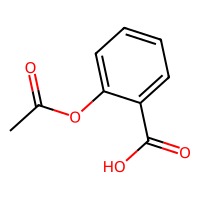
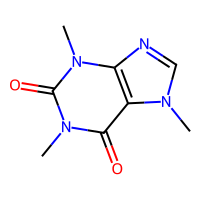
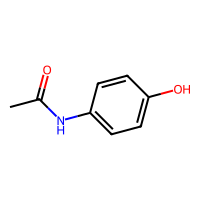
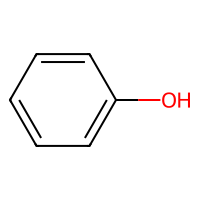
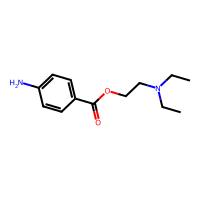
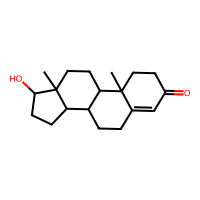
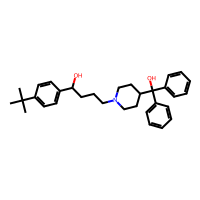
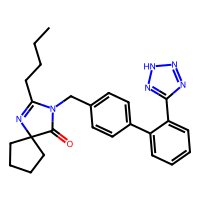
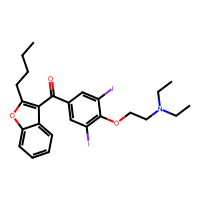

In [ ]:
verdict